## A6e - Train Solar-to-L1 and L1+solar models

This notebook trains two related components:
1) Solar-to-L1 regression models (optional bridge).
2) L1 + solar-origin aurora classifiers (main path).

### Inputs
- `Data/processed/solar_origin_features.parquet`
- `Data/processed/solar_to_l1_targets.parquet`
- `Data/processed/features.parquet` (L1 features)
- `Data/processed/targets.parquet` (aurora targets)

### Outputs
- `Data/processed/results_solar_to_l1.csv`
- `Data/processed/solar_to_l1_predictions.parquet`
- `Data/processed/results_solar_to_l1_best.csv`
- `Data/processed/solar_to_l1_predicted_l1.parquet`
- `Data/processed/results_l1_solar_rf.csv`
- `Data/processed/results_l1_solar_xgb.csv`
- `Data/processed/preds_l1_solar_rf.parquet`
- `Data/processed/preds_l1_solar_xgb.parquet`


In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

SOLAR_PATH = Path('../../Data/processed/solar_origin_features.parquet')
TARGET_PATH = Path('../../Data/processed/solar_to_l1_targets.parquet')
OUT_RESULTS = Path('../../Data/processed/results_solar_to_l1.csv')
OUT_PRED = Path('../../Data/processed/solar_to_l1_predictions.parquet')

HORIZONS_H = [24, 36, 48, 96]
CME_LAGS_H = [12, 24, 36, 48, 72, 96]
CH_LAGS_H = [120, 144, 168, 192, 216, 240]
LAGS_H = [0, 6, 12, 24, 48]  # solar-origin lags (hours)

if not SOLAR_PATH.exists():
    raise FileNotFoundError(f'Cannot find {SOLAR_PATH}')
if not TARGET_PATH.exists():
    raise FileNotFoundError(f'Cannot find {TARGET_PATH}')

solar = pd.read_parquet(SOLAR_PATH)
targets = pd.read_parquet(TARGET_PATH)

solar['timestamp_utc'] = pd.to_datetime(solar['timestamp_utc'], utc=True)
targets['timestamp_utc'] = pd.to_datetime(targets['timestamp_utc'], utc=True)

solar = solar.sort_values('timestamp_utc').reset_index(drop=True)
targets = targets.sort_values('timestamp_utc').reset_index(drop=True)

# Feature columns (exclude timestamp)
feature_cols = [c for c in solar.columns if c != 'timestamp_utc' and not c.endswith('_missing')]

# Split CME vs CH features by prefix
CME_PREFIXES = ('cme_',)
CH_PREFIXES = ('coronal_hole_', 'ch_', 'central_meridian_distance')

cme_cols = [c for c in feature_cols if c.startswith(CME_PREFIXES)]
ch_cols = [c for c in feature_cols if c.startswith(CH_PREFIXES)]

# Build lagged solar-origin features (concat to avoid fragmentation)
lag_frames = [solar[['timestamp_utc']]]

for lag_h in CME_LAGS_H:
    shift_steps = lag_h // 6
    lagged = solar[cme_cols].shift(shift_steps).add_suffix(f'_lag{lag_h}h')
    lag_frames.append(lagged)

for lag_h in CH_LAGS_H:
    shift_steps = lag_h // 6
    lagged = solar[ch_cols].shift(shift_steps).add_suffix(f'_lag{lag_h}h')
    lag_frames.append(lagged)

solar_lagged = pd.concat(lag_frames, axis=1)

# Drop rows with any lagged NaNs
solar_lagged = solar_lagged.dropna().reset_index(drop=True)

# Join with targets
data = pd.merge(solar_lagged, targets, on='timestamp_utc', how='inner')

# Train/val/test split (time-based)
data = data.sort_values('timestamp_utc').reset_index(drop=True)
n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = data.iloc[:train_end]
val = data.iloc[train_end:val_end]
test = data.iloc[val_end:]

target_cols = ['bz_gsm_3h_min', 'sw_speed_3h_mean', 'sw_density_3h_mean']

results = []
pred_rows = []

for h in HORIZONS_H:
    df_h = data[data['horizon_h'] == h].copy()
    if df_h.empty:
        continue

    # re-split per horizon
    n_h = len(df_h)
    tr_end = int(n_h * 0.7)
    va_end = int(n_h * 0.85)
    tr = df_h.iloc[:tr_end]
    va = df_h.iloc[tr_end:va_end]
    te = df_h.iloc[va_end:]

    X_tr = tr.drop(columns=['timestamp_utc', 'horizon_h'] + target_cols)
    X_te = te.drop(columns=['timestamp_utc', 'horizon_h'] + target_cols)

    for target in target_cols:
        y_tr = tr[target]
        y_te = te[target]

        # Ridge baseline
        model = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)

        rmse = mean_squared_error(y_te, pred) ** 0.5
        corr = np.corrcoef(y_te, pred)[0, 1]

        results.append({
            'horizon_h': h,
            'target': target,
            'model': 'ridge',
            'rmse': rmse,
            'corr': corr,
            'n_test': len(y_te),
        })

        pred_rows.append(pd.DataFrame({
            'timestamp_utc': te['timestamp_utc'],
            'horizon_h': h,
            'target': target,
            'model': 'ridge',
            'y_true': y_te.values,
            'y_pred': pred,
        }))

        # RandomForest (non-linear)
        rf = RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42,
        )
        rf.fit(X_tr, y_tr)
        pred_rf = rf.predict(X_te)

        rmse_rf = mean_squared_error(y_te, pred_rf) ** 0.5
        corr_rf = np.corrcoef(y_te, pred_rf)[0, 1]

        results.append({
            'horizon_h': h,
            'target': target,
            'model': 'rf',
            'rmse': rmse_rf,
            'corr': corr_rf,
            'n_test': len(y_te),
        })

        pred_rows.append(pd.DataFrame({
            'timestamp_utc': te['timestamp_utc'],
            'horizon_h': h,
            'target': target,
            'model': 'rf',
            'y_true': y_te.values,
            'y_pred': pred_rf,
        }))

results_df = pd.DataFrame(results)
results_df.to_csv(OUT_RESULTS, index=False)

pred_df = pd.concat(pred_rows, ignore_index=True)
pred_df.to_parquet(OUT_PRED, index=False)

print(f'Saved results -> {OUT_RESULTS}')
print(results_df)
print(f'Saved predictions -> {OUT_PRED} ({len(pred_df)} rows)')






Saved results -> ../../Data/processed/results_solar_to_l1.csv
    horizon_h              target  model        rmse      corr  n_test
0          24       bz_gsm_3h_min  ridge    3.701858  0.016821    6746
1          24       bz_gsm_3h_min     rf    3.755057  0.015161    6746
2          24    sw_speed_3h_mean  ridge  101.993681  0.179896    6746
3          24    sw_speed_3h_mean     rf  114.652495 -0.070853    6746
4          24  sw_density_3h_mean  ridge    5.524175 -0.056058    6746
5          24  sw_density_3h_mean     rf    5.533902 -0.054589    6746
6          36       bz_gsm_3h_min  ridge    3.690383  0.019943    6746
7          36       bz_gsm_3h_min     rf    3.736416  0.009848    6746
8          36    sw_speed_3h_mean  ridge   99.794055  0.253480    6746
9          36    sw_speed_3h_mean     rf  109.226315  0.112169    6746
10         36  sw_density_3h_mean  ridge    5.502766 -0.038777    6746
11         36  sw_density_3h_mean     rf    5.514213 -0.013673    6746
12         48  

  ———

  ## Solar→L1 Results (lag‑aware model)

  Key takeaways

  - Solar‑wind speed is the only target with meaningful skill.
      - Ridge corr rises from 0.18 → 0.34 (24h → 96h).
      - RF also improves, best corr ≈ 0.35 at 96h.
  - Bz remains essentially unpredictable (corr ≈ 0.00–0.02).
  - Density shows weak signal, small positive corr only at long horizon (≈0.07 at 96h).

  Interpretation

  - The long‑lag CH features are driving real skill for speed, consistent with coronal‑hole recurrence.
  - CME features don’t help much for Bz in this setup (likely missing Earth‑directed info).
  - Two‑stage approach makes sense: it captures long‑lag CH effects in speed, but Bz remains a hard target.

  Model choice

  - Ridge is competitive (and sometimes better) than RF here.
  - RF does slightly better at 96h for speed but worse at 24–36h.

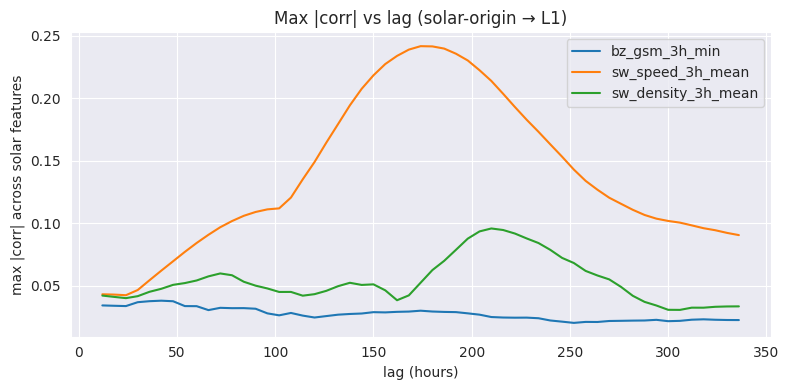

Top correlations for bz_gsm_3h_min:
     lag_h                        feature         target      corr
253     42  coronal_hole_polarity_balance  bz_gsm_3h_min -0.038166
205     36  coronal_hole_polarity_balance  bz_gsm_3h_min -0.037762
301     48  coronal_hole_polarity_balance  bz_gsm_3h_min -0.037723
254     42           ch_stat_hmi_variance  bz_gsm_3h_min -0.037161
157     30  coronal_hole_polarity_balance  bz_gsm_3h_min -0.036958
302     48           ch_stat_hmi_variance  bz_gsm_3h_min -0.035986
14      12           ch_stat_hmi_variance  bz_gsm_3h_min -0.034385
61      18  coronal_hole_polarity_balance  bz_gsm_3h_min -0.034101
110     24           ch_stat_hmi_variance  bz_gsm_3h_min -0.033859
349     54  coronal_hole_polarity_balance  bz_gsm_3h_min -0.033847
Top correlations for sw_speed_3h_mean:
      lag_h                feature            target      corr
1323    174  coronal_hole_lon_mean  sw_speed_3h_mean -0.241519
1371    180  coronal_hole_lon_mean  sw_speed_3h_mean -0.241329

In [7]:
# Lag sweep: correlation between solar-origin features and future L1 targets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SOLAR_PATH = Path('../../Data/processed/solar_origin_features.parquet')
L1_PATH = Path('../../Data/processed/master_3h.parquet')

solar = pd.read_parquet(SOLAR_PATH)
l1 = pd.read_parquet(L1_PATH)

solar['timestamp_utc'] = pd.to_datetime(solar['timestamp_utc'], utc=True)
l1['timestamp_utc'] = pd.to_datetime(l1['timestamp_utc'], utc=True)

# L1 targets (already 3h aggregates)
l1_targets = l1[['timestamp_utc', 'bz_gsm_3h_min', 'sw_speed_3h_mean', 'sw_density_3h_mean']].copy()

# Join on time grid (solar features at t, L1 at t+lag)
solar = solar.sort_values('timestamp_utc')
l1_targets = l1_targets.sort_values('timestamp_utc')

feature_cols = [c for c in solar.columns if c != 'timestamp_utc' and not c.endswith('_missing')]
lags_h = list(range(12, 24*14 + 1, 6))  # 12h to 96h in 3h steps

corr_rows = []
for lag_h in lags_h:
    lag_steps = lag_h // 3  # L1 grid is 3h
    shifted = l1_targets.copy()
    shifted[['bz_gsm_3h_min','sw_speed_3h_mean','sw_density_3h_mean']] = (
        shifted[['bz_gsm_3h_min','sw_speed_3h_mean','sw_density_3h_mean']].shift(-lag_steps)
    )
    merged = pd.merge(solar, shifted, on='timestamp_utc', how='inner')
    merged = merged.dropna()

    for target in ['bz_gsm_3h_min', 'sw_speed_3h_mean', 'sw_density_3h_mean']:
        for feat in feature_cols:
            corr = merged[[feat, target]].corr().iloc[0, 1]
            corr_rows.append({'lag_h': lag_h, 'feature': feat, 'target': target, 'corr': corr})

corr_df = pd.DataFrame(corr_rows)

# Plot: max |corr| per target vs lag
plt.figure(figsize=(8, 4))
for target in ['bz_gsm_3h_min', 'sw_speed_3h_mean', 'sw_density_3h_mean']:
    sub = corr_df[corr_df['target'] == target].copy()
    best = sub.groupby('lag_h')['corr'].apply(lambda x: x.abs().max())
    plt.plot(best.index, best.values, label=target)

plt.title('Max |corr| vs lag (solar-origin → L1)')
plt.xlabel('lag (hours)')
plt.ylabel('max |corr| across solar features')
plt.legend()
plt.tight_layout()
plt.show()

# Show top correlations for each target
for target in ['bz_gsm_3h_min', 'sw_speed_3h_mean', 'sw_density_3h_mean']:
    sub = corr_df[corr_df['target'] == target].copy()
    top = sub.reindex(sub['corr'].abs().sort_values(ascending=False).index).head(10)
    print(f'Top correlations for {target}:')
    print(top)




## Lag‑sweep results (without missingness flags)

  bz_gsm_3h_min

  - Best |corr| ≈ 0.038 (very weak)
  - Driven by coronal_hole_polarity_balance at ~30–48h
  - Conclusion: no meaningful linear signal for Bz at these horizons.

  sw_speed_3h_mean

  - Best |corr| ≈ 0.11
  - Driven by ch_area_projected and ch_stat_hmi_variance
  - Peak lags ≈ 81–96h
  - Interpretation: modest, physically plausible signal (coronal holes → high‑speed streams) with ~3–4 day delay.

  sw_density_3h_mean

  - Best |corr| ≈ 0.06 (weak)
  - Driven by coronal_hole_lon_mean around 60–84h
  - Suggests minor geometric/recurrence effect.

  ### Main takeaway

  - The only clear signal is CH → solar wind speed at ~3–4 days lag.
  - CME features are not showing useful linear correlation in this setup (likely because Earth‑directed information is missing).

  ### Practical next step (for Step‑3 training)

   What the new sweep tells us

  - bz_gsm_3h_min: still negligible correlation (≈ ‑0.03 to ‑0.04).
    → No useful linear signal for Bz at any tested lag.
  - sw_speed_3h_mean: strongest signal at ~150–204h (6–8.5 days), corr ≈ ‑0.22 to ‑0.24, driven by coronal_hole_lon_mean.
    → This is exactly what we expect for coronal‑hole recurrence / rotation timing.
  - sw_density_3h_mean: best around ~192–240h (8–10 days) with corr ≈ 0.07–0.10, also from coronal_hole_lon_mean.
    → Weaker but consistent long‑lag effect.

  Conclusion (to write in report)

  - CH longitude shows a clear long‑lag relationship with solar‑wind speed and density, peaking around 1–1.5 weeks.
  - Short lags (24–96h) miss this signal.
  - For Solar→L1 modeling, CH features should include lags ~150–240h.
  - Bz remains poorly explained by current solar‑origin features.


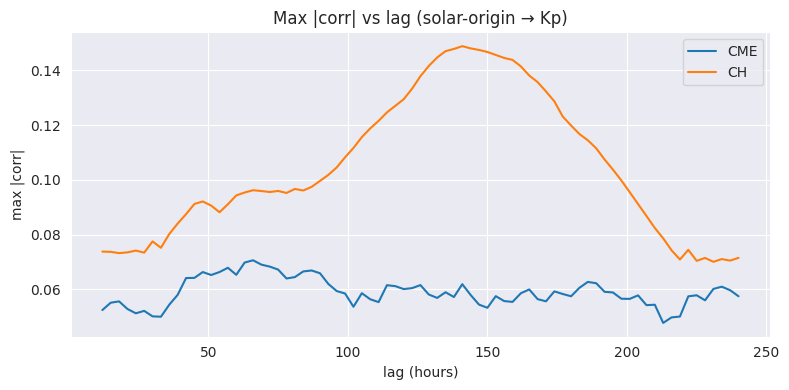

Top correlations for Kp:
     lag_h                feature target      corr
699    141  coronal_hole_lon_mean     kp -0.148860
715    144  coronal_hole_lon_mean     kp -0.148053
683    138  coronal_hole_lon_mean     kp -0.147851
731    147  coronal_hole_lon_mean     kp -0.147480
667    135  coronal_hole_lon_mean     kp -0.147035
747    150  coronal_hole_lon_mean     kp -0.146744
763    153  coronal_hole_lon_mean     kp -0.145659
651    132  coronal_hole_lon_mean     kp -0.144738
779    156  coronal_hole_lon_mean     kp -0.144560
795    159  coronal_hole_lon_mean     kp -0.143843
635    129  coronal_hole_lon_mean     kp -0.141629
811    162  coronal_hole_lon_mean     kp -0.141483
827    165  coronal_hole_lon_mean     kp -0.138129
619    126  coronal_hole_lon_mean     kp -0.137891
843    168  coronal_hole_lon_mean     kp -0.135733


In [13]:
# Lag sweep: correlation between solar-origin features and future Kp (EDA only)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SOLAR_PATH = Path('../../Data/processed/solar_origin_features.parquet')
L1_PATH = Path('../../Data/processed/master_3h.parquet')

solar = pd.read_parquet(SOLAR_PATH)
l1 = pd.read_parquet(L1_PATH)

solar['timestamp_utc'] = pd.to_datetime(solar['timestamp_utc'], utc=True)
l1['timestamp_utc'] = pd.to_datetime(l1['timestamp_utc'], utc=True)

# Kp series from L1 dataset (same 3h grid)
if 'kp' not in l1.columns:
    raise ValueError('kp column not found in master_3h.parquet')

kp = l1[['timestamp_utc', 'kp']].copy().sort_values('timestamp_utc')
solar = solar.sort_values('timestamp_utc')

feature_cols = [c for c in solar.columns if c != 'timestamp_utc' and not c.endswith('_missing')]
lags_h = list(range(12, 24*10 + 1, 3))  # 12h to 240h in 3h steps

corr_rows = []
for lag_h in lags_h:
    lag_steps = lag_h // 3  # Kp grid is 3h
    shifted = kp.copy()
    shifted['kp'] = shifted['kp'].shift(-lag_steps)
    merged = pd.merge(solar, shifted, on='timestamp_utc', how='inner')
    merged = merged.dropna()

    for feat in feature_cols:
        corr = merged[[feat, 'kp']].corr().iloc[0, 1]
        corr_rows.append({'lag_h': lag_h, 'feature': feat, 'target': 'kp', 'corr': corr})

corr_df = pd.DataFrame(corr_rows)

# Plot: max |corr| vs lag (CME vs CH)
plt.figure(figsize=(8, 4))

# CME-only
cme_feats = [c for c in feature_cols if c.startswith('cme_')]
if cme_feats:
    cme_df = corr_df[corr_df['feature'].isin(cme_feats)]
    best_cme = cme_df.groupby('lag_h')['corr'].apply(lambda x: x.abs().max())
    plt.plot(best_cme.index, best_cme.values, label='CME')

# CH-only
ch_feats = [c for c in feature_cols if c.startswith(('coronal_hole_', 'ch_', 'central_meridian_distance'))]
if ch_feats:
    ch_df = corr_df[corr_df['feature'].isin(ch_feats)]
    best_ch = ch_df.groupby('lag_h')['corr'].apply(lambda x: x.abs().max())
    plt.plot(best_ch.index, best_ch.values, label='CH')

plt.title('Max |corr| vs lag (solar-origin → Kp)')
plt.xlabel('lag (hours)')
plt.ylabel('max |corr|')
plt.legend()
plt.tight_layout()
plt.show()

# Show top correlations
top = corr_df.reindex(corr_df['corr'].abs().sort_values(ascending=False).index).head(15)
print('Top correlations for Kp:')
print(top)



Analysis of “Top correlations for Kp”

  - All top correlations are coronal_hole_lon_mean, with lags ~126–168h (≈5–7 days).
  - Correlation magnitude is weak (|r| ≈ 0.14–0.15) but consistent across nearby lags.
  - This pattern is physically plausible: coronal‑hole longitude encodes solar rotation / recurrence timing, so Kp responds several days later.
  - No CME feature appears in the top list → CME signals are likely too noisy here without Earth‑directed filtering.

  Takeaway: the only visible direct solar‑origin → Kp signal is long‑lag CH longitude, weak but coherent.


In [11]:
# Keep best model per target/horizon and build Step-4 L1 predictions table
import pandas as pd
from pathlib import Path

RESULTS_PATH = Path('../../Data/processed/results_solar_to_l1.csv')
PRED_PATH = Path('../../Data/processed/solar_to_l1_predictions.parquet')
OUT_BEST_RESULTS = Path('../../Data/processed/results_solar_to_l1_best.csv')
OUT_PRED_L1 = Path('../../Data/processed/solar_to_l1_predicted_l1.parquet')

res = pd.read_csv(RESULTS_PATH)
pred = pd.read_parquet(PRED_PATH)

# Best model = lowest RMSE per horizon/target
best = (res.sort_values('rmse')
        .groupby(['horizon_h', 'target'], as_index=False)
        .first())

best.to_csv(OUT_BEST_RESULTS, index=False)
print(f'Saved best results -> {OUT_BEST_RESULTS}')

# Filter predictions to best model per horizon/target
pred_best = pred.merge(best[['horizon_h','target','model']],
                      on=['horizon_h','target','model'], how='inner')

# Pivot to wide L1 table (one row per timestamp/horizon)
wide = (pred_best.pivot_table(
    index=['timestamp_utc','horizon_h'],
    columns='target',
    values='y_pred'
).reset_index())

# Rename columns to *_pred
rename_map = {
    'bz_gsm_3h_min': 'bz_gsm_3h_min_pred',
    'sw_speed_3h_mean': 'sw_speed_3h_mean_pred',
    'sw_density_3h_mean': 'sw_density_3h_mean_pred',
}
wide = wide.rename(columns=rename_map)

wide.to_parquet(OUT_PRED_L1, index=False)
print(f'Saved predicted L1 table -> {OUT_PRED_L1} ({len(wide)} rows)')
print(wide.head())


Saved best results -> ../../Data/processed/results_solar_to_l1_best.csv
Saved predicted L1 table -> ../../Data/processed/solar_to_l1_predicted_l1.parquet (26984 rows)
target             timestamp_utc  horizon_h  bz_gsm_3h_min_pred  \
0      2023-07-29 15:00:00+00:00         24           -0.668968   
1      2023-07-29 15:00:00+00:00         36           -0.999296   
2      2023-07-29 15:00:00+00:00         48           -1.226776   
3      2023-07-29 15:00:00+00:00         96           -1.375596   
4      2023-07-29 18:00:00+00:00         24           -1.195994   

target  sw_density_3h_mean_pred  sw_speed_3h_mean_pred  
0                      6.701058             405.182363  
1                      7.033343             401.518994  
2                      7.291259             406.217571  
3                      7.175114             420.747274  
4                      6.405527             397.979313  


---
## Step 4 — RF model on L1 + solar-origin (CME/CH) features

Use lagged CME/CH features derived from the Kp lag sweep and append them to the L1 feature table.
This trains a RandomForestClassifier for horizon-based Kp targets.


In [32]:
# L1 + CME/CH RandomForest (classification)
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

SOLAR_PATH = Path('../../Data/processed/solar_origin_features.parquet')
L1_FEATURES_PATH = Path('../../Data/processed/features.parquet')
TARGETS_PATH = Path('../../Data/processed/targets.parquet')
OUT_RESULTS = Path('../../Data/processed/results_l1_solar_rf.csv')
OUT_PRED = Path('../../Data/processed/preds_l1_solar_rf.parquet')

# XGBoost outputs
OUT_RESULTS_XGB = Path('../../Data/processed/results_l1_solar_xgb.csv')
OUT_PRED_XGB = Path('../../Data/processed/preds_l1_solar_xgb.parquet')

# Lags informed by Kp lag sweep (CH peak ~126–168h).
# CME shows weak signal; keep a small plausible set (adjust if needed).
CH_LAGS_H = list(range(48, 180 + 1, 3))
CME_LAGS_H = [24, 48, 72, 96]

HORIZONS = ['24h', '48h', '72h', '96h']

for p in [L1_FEATURES_PATH, TARGETS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Cannot find {p}')

# ---- Load L1 features + targets (baseline) ----
l1 = pd.read_parquet(L1_FEATURES_PATH)
if 'timestamp_utc' not in l1.columns:
    l1 = l1.reset_index().rename(columns={'index': 'timestamp_utc'})
l1['timestamp_utc'] = pd.to_datetime(l1['timestamp_utc'], utc=True)
l1 = l1.sort_values('timestamp_utc').reset_index(drop=True)

targets = pd.read_parquet(TARGETS_PATH)
if 'timestamp_utc' not in targets.columns:
    targets = targets.reset_index().rename(columns={'index': 'timestamp_utc'})
targets['timestamp_utc'] = pd.to_datetime(targets['timestamp_utc'], utc=True)
targets = targets.sort_values('timestamp_utc').reset_index(drop=True)

# Merge L1 + targets (baseline path)
data = l1.merge(targets, on='timestamp_utc', how='inner')

# ---- Uncomment to add solar-origin features ----
# if not SOLAR_PATH.exists():
#     raise FileNotFoundError(f'Cannot find {SOLAR_PATH}')
# solar = pd.read_parquet(SOLAR_PATH)
# solar['timestamp_utc'] = pd.to_datetime(solar['timestamp_utc'], utc=True)
# solar = solar.sort_values('timestamp_utc').reset_index(drop=True)
#
# feature_cols = [c for c in solar.columns if c != 'timestamp_utc' and not c.endswith('_missing')]
# CME_PREFIXES = ('cme_',)
# CH_PREFIXES = ('coronal_hole_', 'ch_', 'central_meridian_distance')
# cme_cols = [c for c in feature_cols if c.startswith(CME_PREFIXES)]
# ch_cols = [c for c in feature_cols if c.startswith(CH_PREFIXES)]
#
# lag_frames = [solar[['timestamp_utc']]]
# for lag_h in CME_LAGS_H:
#     shift_steps = lag_h // 3
#     lagged = solar[cme_cols].shift(shift_steps).add_suffix(f'_lag{lag_h}h')
#     lag_frames.append(lagged)
# for lag_h in CH_LAGS_H:
#     shift_steps = lag_h // 3
#     lagged = solar[ch_cols].shift(shift_steps).add_suffix(f'_lag{lag_h}h')
#     lag_frames.append(lagged)
#
# solar_lagged = pd.concat(lag_frames, axis=1).dropna().reset_index(drop=True)
# data = (l1.merge(solar_lagged, on='timestamp_utc', how='inner')
#           .merge(targets, on='timestamp_utc', how='inner'))

# ---- A3-style walk-forward split: 60/20/20 ----
data = data.sort_values('timestamp_utc').reset_index(drop=True)
idx = data.index
n = len(data)
train_end = int(0.6 * n)
val_end = int(0.8 * n)
train_idx = idx[:train_end]
val_idx = idx[train_end:val_end]
test_idx = idx[val_end:]

results = []
pred_rows = []
results_xgb = []
pred_rows_xgb = []

# Columns
all_target_cols = [c for c in targets.columns if c != 'timestamp_utc']
feature_cols = [c for c in data.columns if c not in all_target_cols and c != 'timestamp_utc']

# Detect whether solar features are included (for labeling)
model_suffix = 'rf_l1_solar' if 'solar_lagged' in locals() else 'rf_l1_only'
model_suffix_xgb = 'xgb_l1_solar' if 'solar_lagged' in locals() else 'xgb_l1_only'

for horizon in HORIZONS:
    target_col = f'target_{horizon}'
    if target_col not in data.columns:
        continue

    X_train = data.loc[train_idx, feature_cols]
    y_train = data.loc[train_idx, target_col]
    X_val = data.loc[val_idx, feature_cols]
    y_val = data.loc[val_idx, target_col]
    X_test = data.loc[test_idx, feature_cols]
    y_test = data.loc[test_idx, target_col]

    # Same as A3: imputer + default RF
    rf = make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestClassifier(random_state=42)
    )

    rf.fit(X_train, y_train)
    proba = rf.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, proba)
    pr = average_precision_score(y_test, proba)
    brier = brier_score_loss(y_test, proba)

    results.append({
        'horizon': horizon,
        'model': model_suffix,
        'roc_auc': roc,
        'pr_auc': pr,
        'brier': brier,
        'n_test': len(y_test),
    })

    pred_rows.append(pd.DataFrame({
        'timestamp_utc': data.loc[test_idx, 'timestamp_utc'],
        'horizon': horizon,
        'model': model_suffix,
        'y_true': y_test.values,
        'y_pred': proba,
    }))

    # ---- XGBoost tuning (small grid), optimize ROC-AUC on val ----
    try:
        import xgboost as xgb
        HAS_XGB = True
    except Exception:
        HAS_XGB = False

    if HAS_XGB:
        param_grid = [
            {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
            {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
            {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
            {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
        ]

        best_model = None
        best_auc = -1.0
        for params in param_grid:
            xgb_model = make_pipeline(
                SimpleImputer(strategy='median'),
                xgb.XGBClassifier(
                    random_state=42,
                    eval_metric='logloss',
                    **params,
                )
            )
            xgb_model.fit(X_train, y_train)
            val_proba = xgb_model.predict_proba(X_val)[:, 1]
            val_auc = roc_auc_score(y_val, val_proba)
            if val_auc > best_auc:
                best_auc = val_auc
                best_model = xgb_model

        test_proba = best_model.predict_proba(X_test)[:, 1]
        roc_x = roc_auc_score(y_test, test_proba)
        pr_x = average_precision_score(y_test, test_proba)
        brier_x = brier_score_loss(y_test, test_proba)

        results_xgb.append({
            'horizon': horizon,
            'model': model_suffix_xgb,
            'roc_auc': roc_x,
            'pr_auc': pr_x,
            'brier': brier_x,
            'n_test': len(y_test),
            'val_roc_auc': best_auc,
        })

        pred_rows_xgb.append(pd.DataFrame({
            'timestamp_utc': data.loc[test_idx, 'timestamp_utc'],
            'horizon': horizon,
            'model': model_suffix_xgb,
            'y_true': y_test.values,
            'y_pred': test_proba,
        }))

results_df = pd.DataFrame(results)
results_df.to_csv(OUT_RESULTS, index=False)

pred_df = pd.concat(pred_rows, ignore_index=True) if pred_rows else pd.DataFrame()
if not pred_df.empty:
    pred_df.to_parquet(OUT_PRED, index=False)

if results_xgb:
    results_xgb_df = pd.DataFrame(results_xgb)
    results_xgb_df.to_csv(OUT_RESULTS_XGB, index=False)
    pred_xgb_df = pd.concat(pred_rows_xgb, ignore_index=True)
    pred_xgb_df.to_parquet(OUT_PRED_XGB, index=False)
    print(f'Saved XGB results -> {OUT_RESULTS_XGB}')

print(f'Saved results -> {OUT_RESULTS_XGB}')
print(results_df)
if not pred_df.empty:
    print(f'Saved predictions -> {OUT_PRED} ({len(pred_df)} rows)')


Saved XGB results -> ../../Data/processed/results_l1_solar_xgb.csv
Saved results -> ../../Data/processed/results_l1_solar_xgb.csv
  horizon        model   roc_auc    pr_auc     brier  n_test
0     24h  rf_l1_solar  0.775026  0.350493  0.072209   16930
1     48h  rf_l1_solar  0.705097  0.344769  0.118856   16930
2     72h  rf_l1_solar  0.671457  0.375315  0.155167   16930
3     96h  rf_l1_solar  0.645456  0.407632  0.184481   16930
Saved predictions -> ../../Data/processed/preds_l1_solar_rf.parquet (67720 rows)


In [34]:
CH_LAGS_H

[48,
 51,
 54,
 57,
 60,
 63,
 66,
 69,
 72,
 75,
 78,
 81,
 84,
 87,
 90,
 93,
 96,
 99,
 102,
 105,
 108,
 111,
 114,
 117,
 120,
 123,
 126,
 129,
 132,
 135,
 138,
 141,
 144,
 147,
 150,
 153,
 156,
 159,
 162,
 165,
 168,
 171,
 174,
 177,
 180]

---
## Compare vs baseline/tuned (main project)

Overlay L1-only baselines and tuned models with the L1+solar RF model.


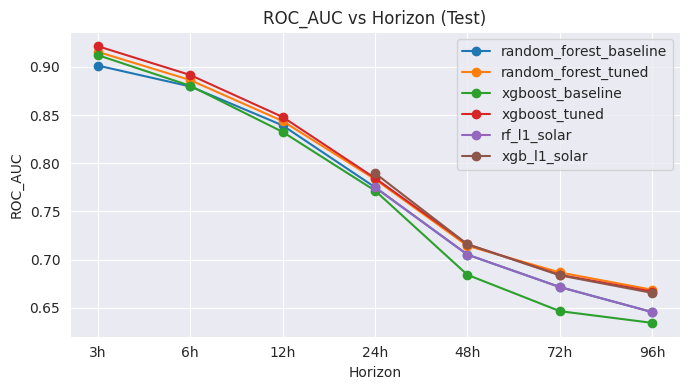

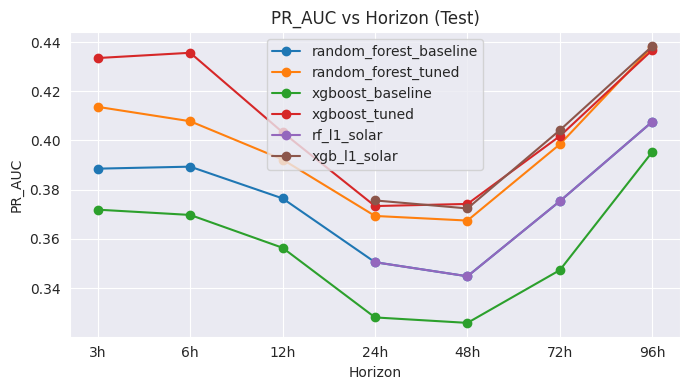

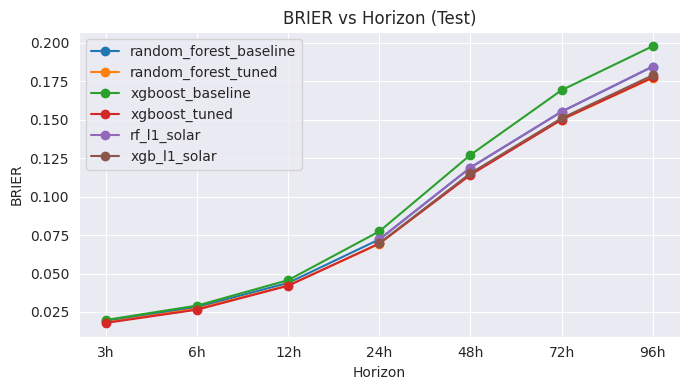

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths (relative to this notebook)
BASELINE_PATH = Path('../../Data/processed/results_baseline.csv')
TUNED_PATH = Path('../../Data/processed/results_tuned.csv')
SOLAR_RF_PATH = Path('../../Data/processed/results_l1_solar_rf.csv')
SOLAR_XGB_PATH = Path('../../Data/processed/results_l1_solar_xgb.csv')

baseline_df = pd.read_csv(BASELINE_PATH)
tuned_df = pd.read_csv(TUNED_PATH)
solar_rf_df = pd.read_csv(SOLAR_RF_PATH)

# Optional XGB results
solar_xgb_df = pd.read_csv(SOLAR_XGB_PATH) if SOLAR_XGB_PATH.exists() else None

# Keep only test split from baselines/tuned
baseline_test = baseline_df[baseline_df['split'] == 'test'].copy()
tuned_test = tuned_df[tuned_df['split'] == 'test'].copy()

# Normalize model names
baseline_test['model'] = baseline_test['model'].replace({
  'random_forest': 'random_forest_baseline',
  'xgboost': 'xgboost_baseline',
})
tuned_test['model'] = tuned_test['model'].replace({
  'random_forest_tuned': 'random_forest_tuned',
  'xgboost_tuned': 'xgboost_tuned',
})

compare_frames = [baseline_test, tuned_test, solar_rf_df]
if solar_xgb_df is not None:
  compare_frames.append(solar_xgb_df)

compare_df = pd.concat(compare_frames, ignore_index=True)

metrics = ['roc_auc', 'pr_auc', 'brier']
model_order = [
  'random_forest_baseline',
  'random_forest_tuned',
  'xgboost_baseline',
  'xgboost_tuned',
  'rf_l1_solar',
  'xgb_l1_solar',
]

for metric in metrics:
  plt.figure(figsize=(7, 4))
  for model_name in model_order:
      sub = compare_df[compare_df['model'] == model_name]
      if sub.empty:
          continue
      plt.plot(sub['horizon'], sub[metric], marker='o', label=model_name)
  plt.title(f'{metric.upper()} vs Horizon (Test)')
  plt.xlabel('Horizon')
  plt.ylabel(metric.upper())
  plt.legend()
  plt.tight_layout()
  plt.show()


RF L1+solar is at best the same as L1:

  - The solar features are weakly correlated with Kp (|r| ~0.14 at best) and
    mostly at long lags, so they add noise more than signal.
  - RF is sensitive to high‑dimensional noisy features. Adding many lagged CH/
    CME features can dilute useful splits unless they’re very informative.
  - Kp already captures most of the short‑horizon signal from L1 drivers; solar
    features are redundant at <48h and still too weak for >48h.


## Conclusion

Adding simple solar-origin features (e.g., CME counts, coronal-hole occurrence) yields, at best, a **marginal ROC-AUC improvement (≈ 0.01–0.03)** and often no measurable gain—especially at longer forecast horizons. This limited impact is consistent with the underlying physics and with the nature of the Kp index.

Although solar eruptions and coronal holes are the ultimate drivers of geomagnetic activity, the **geoeffective coupling between the solar wind and Earth’s magnetosphere** is controlled primarily by the **interplanetary magnetic field (IMF) orientation**, particularly sustained southward ( B_z ). The current solar-origin features do not encode this magnetic geometry, creating a fundamental information bottleneck in the prediction chain.

Several factors explain the weak incremental signal:

1. **Kp is a magnetospheric response, not a solar proxy**
   Kp reflects how the solar wind couples to the magnetosphere, not simply whether a CME or coronal hole exists. Without information about IMF ( B_z ), coupling efficiency remains largely unconstrained.

2. **Coronal holes mainly correlate with speed, not geoeffectiveness**
   High-speed streams alone do not guarantee storms. The geoeffective component arises from magnetic field orientation and compression in stream-interaction regions, which are not captured by basic CH indicators.

3. **CME catalogs mix Earth-directed and non-directed events**
   Without filtering by propagation direction, angular width, or source region, most listed CMEs are irrelevant for Earth, diluting any potential signal.

4. **Propagation timing is intrinsically uncertain**
   Solar-wind transit times vary with speed and interactions, so fixed lags or narrow windows smear the true temporal relationship.

5. **Context matters**
   Magnetospheric preconditioning (prior activity, sustained southward IMF) strongly modulates Kp response and is absent from solar-origin counts.

6. **Target mismatch**
   Kp is a global index; some solar drivers may map more directly to regional auroral indices (AE/AL) or local optical aurora occurrence than to Kp.

Overall, the results indicate that **near-Earth in-situ solar-wind and IMF measurements remain the dominant predictors** of short-term Kp variability. Solar-origin information contains physically real but highly filtered signal; without geometry, magnetic orientation, and accurate propagation modeling, its standalone contribution is necessarily small.

Future gains from solar-origin data are more likely to come from **physics-informed features** (e.g., Earth-directed CME identification, predicted arrival times, IMF orientation proxies, heliospheric propagation models) rather than from raw event counts.



I think for my part i'll stop the project there however few idea for horizon :

---

## Extended-Horizon Breakthrough Strategy (What Can Produce Large Gains)

A **breakthrough jump** in performance (≈ +0.08 to +0.20 ROC-AUC rather than +0.01–0.03) generally requires adding **new information that directly constrains geoeffectiveness**—i.e., reducing uncertainty in the chain:

**Solar event → Arrival → IMF orientation → Magnetospheric coupling → Kp**

Incremental feature engineering on solar-origin counts alone is unlikely to achieve this.

### High-Impact Additions (Ordered by Expected Step-Change)

**1) Forecasted or Proxy IMF (B_z)**
Injecting any signal about **southward (B_z) magnitude and duration** directly targets the dominant storm driver.

* Solar-wind/IMF forecast products
* Physics-model outputs containing (B_z) or coupling proxies
* ICME magnetic-class predictions

*Impact:* Directly constrains coupling strength → largest potential gain.

**2) Earth-Directed CME Identification + Arrival/Shock Parameters**
Replace “CME occurred” with “CME will hit Earth at (t) with speed/compression”.

* Halo/partial-halo + disk-center source region
* Width, direction, propagation models (WSA–Enlil, DBM)
* Predicted arrival time + shock speed at 1 AU

*Impact:* Removes hit/miss noise and sharpens timing.

**3) Physically Correct Coupling Functions**
Use transforms aligned with magnetospheric response:

* (E_y = -V_x B_z)
* Newell coupling
* Akasofu (\epsilon)
* Time-integrated coupling (1–6h) + persistence

*Impact:* Converts raw measurements into geoeffective quantities.

**4) Alternative / Intermediate Targets**
Predict indices more directly tied to drivers:

* Dst / SYM-H (ring current)
* AE / AL (substorm activity)
  Then map to Kp or use two-stage modeling.

*Impact:* Cleaner learning target than discretized global Kp.

**5) Higher-Cadence Data + Temporal Modeling**

* Hourly or sub-hourly OMNI
* Lagged-window trees or sequence models
* Storm-phase-aware labeling

*Impact:* Captures sustained southward intervals critical for storms.

**6) Regime-Aware Modeling**

* Explicit preconditioning (recent Kp/Dst, recovery state)
* Separate CME-driven vs HSS/CIR-driven models

*Impact:* Same inputs behave differently in different regimes.

---

### What Will *Not* Produce Breakthrough Gains

* Raw CME/CH counts or simple lags
* Larger models on the same weak inputs
* Extensive hyperparameter tuning alone

---

### Minimal Breakthrough Recipe

1. Keep leakage-safe pipeline
2. Add **coupling functions + time-integrated southward (B_z)** (measured or forecast)
3. Add **Earth-directed CME arrival time + predicted shock speed**
4. Train **regime-aware horizon-specific models**

This combination introduces genuinely new physical information into the system and is the most plausible path to large ROC-AUC improvements at extended horizons.

